In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_clustered.csv")

print("All columns in dataset:")
print(df.columns.tolist())

All columns in dataset:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'cluster', 'pca1', 'pca2']


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_clustered.csv")

# Original audio features
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 
            'valence', 'tempo', 'duration_ms', 'explicit']

# Add genre as features (same as Day 8)
top_genres = df['track_genre'].value_counts().head(20).index
df['genre_grouped'] = df['track_genre'].apply(lambda x: x if x in top_genres else 'other')
genre_dummies = pd.get_dummies(df['genre_grouped'], prefix='genre')

# NEW: Add cluster as a feature
cluster_dummies = pd.get_dummies(df['cluster'], prefix='cluster')

# NEW: Add interaction features
df['dance_energy'] = df['danceability'] * df['energy']
df['valence_energy'] = df['valence'] * df['energy']

interaction_features = ['dance_energy', 'valence_energy']

# Combine everything
X_final = pd.concat([df[features], df[interaction_features], genre_dummies, cluster_dummies], axis=1)
y = df['popularity']

print("Total features:", X_final.shape[1])
print(X_final.columns.tolist())

Total features: 39
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'explicit', 'dance_energy', 'valence_energy', 'genre_acoustic', 'genre_afrobeat', 'genre_alt-rock', 'genre_ambient', 'genre_anime', 'genre_black-metal', 'genre_bluegrass', 'genre_breakbeat', 'genre_cantopop', 'genre_chicago-house', 'genre_club', 'genre_comedy', 'genre_disney', 'genre_forro', 'genre_happy', 'genre_heavy-metal', 'genre_j-idol', 'genre_other', 'genre_sleep', 'genre_study', 'genre_tango', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
r2_lr_final = r2_score(y_test, lr.predict(X_test))

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=150, max_depth=18, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
r2_rf_final = r2_score(y_test, rf.predict(X_test))

# Model 3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
r2_gb_final = r2_score(y_test, gb.predict(X_test))

print("Model Comparison (with cluster + interaction features):")
print(f"Linear Regression R²: {r2_lr_final:.3f}")
print(f"Random Forest R²:     {r2_rf_final:.3f}")
print(f"Gradient Boosting R²: {r2_gb_final:.3f}")
print(f"\nPrevious best (Random Forest, no cluster/interaction): R² = 0.265")

Model Comparison (with cluster + interaction features):
Linear Regression R²: 0.081
Random Forest R²:     0.263
Gradient Boosting R²: 0.166

Previous best (Random Forest, no cluster/interaction): R² = 0.265


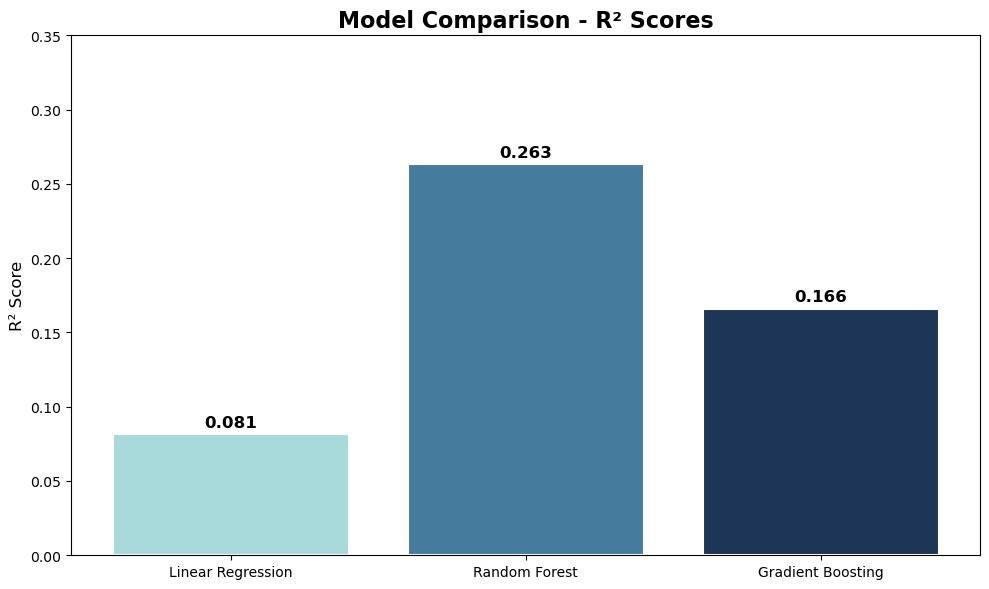

Chart saved!


In [7]:
# Model comparison chart
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
r2_scores = [r2_lr_final, r2_rf_final, r2_gb_final]
colors = ['#A8DADC', '#457B9D', '#1D3557']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='white', linewidth=1.5)

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Model Comparison - R² Scores', fontsize=16, fontweight='bold')
plt.ylabel('R² Score', fontsize=12)
plt.ylim(0, 0.35)
plt.tight_layout()
plt.savefig('chart11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
print("Day 9 Summary - Complete Model Comparison:")
print(f"Linear Regression R²:  0.030 → 0.081 (with engineered features)")
print(f"Random Forest R²:      0.189 → 0.263 (with engineered features)")
print(f"Gradient Boosting R²:  0.166 (new model added)")
print(f"\nBest model: Random Forest with genre + interaction features")
print(f"Key insight: Audio features explain ~26% of popularity variance")
print(f"Remaining 74% likely driven by artist fame, marketing, playlists")
print("\nDay 9 complete!")

Day 9 Summary - Complete Model Comparison:
Linear Regression R²:  0.030 → 0.081 (with engineered features)
Random Forest R²:      0.189 → 0.263 (with engineered features)
Gradient Boosting R²:  0.166 (new model added)

Best model: Random Forest with genre + interaction features
Key insight: Audio features explain ~26% of popularity variance
Remaining 74% likely driven by artist fame, marketing, playlists

Day 9 complete!
